# Dataset-Level Attribution Analysis

This notebook computes and analyzes attribution patterns across the full dataset:

1. **Average feature attribution** for Activity, Resource, and temporal features
2. **Attribution by categorical value** for top-5 most common activities and resources
3. **Test mode** for quick validation with a subset

**Note**: Full dataset computation can take significant time. Use test mode first.

## 1. Setup

In [1]:
# Path setup and config import
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

# Add both project root and src/ to path (src/ needed for pickle compatibility)
if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))
if str(_current / 'src') not in sys.path:
    sys.path.insert(0, str(_current / 'src'))

from src.interpretability.config.domestic_declarations_config import CONFIG
print(f"Dataset: {CONFIG.dataset_name}")

Dataset: DomesticDeclarations


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from collections import defaultdict
import pickle
import random

from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation
from src.interpretability import InterpretabilityTool

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Reproducibility
SEED = CONFIG.seed
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
# Load model and data
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
device = torch.device('cpu')
model = model.to(device)

test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)

eval_helper = Evaluation(
    model=model,
    dataset=test_dataset,
    concept_name=CONFIG.concept_name,
    growing_num_values=CONFIG.growing_num_values,
    all_cat=CONFIG.all_cat,
    all_num=CONFIG.all_num
)

tool = InterpretabilityTool(model, model.data_set_categories, device=device)

print(f"Loaded {len(test_dataset)} samples")
print(f"Available cases: {len(eval_helper.cases)}")

Data set categories:  ([('Activity', 18, {'Declaration APPROVED by ADMINISTRATION': 1, 'Declaration APPROVED by BUDGET OWNER': 2, 'Declaration APPROVED by PRE_APPROVER': 3, 'Declaration FINAL_APPROVED by SUPERVISOR': 4, 'Declaration FOR_APPROVAL by ADMINISTRATION': 5, 'Declaration FOR_APPROVAL by SUPERVISOR': 6, 'Declaration REJECTED by ADMINISTRATION': 7, 'Declaration REJECTED by BUDGET OWNER': 8, 'Declaration REJECTED by EMPLOYEE': 9, 'Declaration REJECTED by MISSING': 10, 'Declaration REJECTED by PRE_APPROVER': 11, 'Declaration REJECTED by SUPERVISOR': 12, 'Declaration SAVED by EMPLOYEE': 13, 'Declaration SUBMITTED by EMPLOYEE': 14, 'EOS': 15, 'Payment Handled': 16, 'Request Payment': 17}), ('Resource', 4, {'EOS': 1, 'STAFF MEMBER': 2, 'SYSTEM': 3}), ('Role', 9, {'ADMINISTRATION': 1, 'BUDGET OWNER': 2, 'EMPLOYEE': 3, 'EOS': 4, 'MISSING': 5, 'PRE_APPROVER': 6, 'SUPERVISOR': 7, 'UNDEFINED': 8})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('s

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/v

Loaded 15471 samples
Available cases: 2100


## 2. Configuration

In [4]:
# ============================================================
# CONFIGURATION
# ============================================================
TEST_MODE = False          # Set to False for full dataset analysis
TEST_SAMPLE_SIZE = 50     # Number of samples in test mode
IG_STEPS = 30             # Integration steps (reduce for speed)
TARGET = CONFIG.concept_name  # Attribution target

# Get ALL input features from the model (not a subset)
# This ensures attribution is always computed w.r.t. all input features
cat_categories, num_categories = model.data_set_categories
ALL_CAT_FEATURES = [name for name, _, _ in cat_categories]
ALL_NUM_FEATURES = [name for name, _, _ in num_categories]
ALL_FEATURES = ALL_CAT_FEATURES + ALL_NUM_FEATURES

print(f"Mode: {'TEST' if TEST_MODE else 'FULL'}")
print(f"All input features ({len(ALL_FEATURES)} total):")
print(f"  Categorical: {ALL_CAT_FEATURES}")
print(f"  Numerical: {ALL_NUM_FEATURES}")

Mode: FULL
All input features (8 total):
  Categorical: ['Activity', 'Resource', 'Role']
  Numerical: ['case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day', 'Amount']


## 3. Prepare Samples

In [5]:
# Collect all prefix-suffix pairs
all_samples = []

for case_name, full_case in tqdm(eval_helper.cases.items(), desc="Collecting samples"):
    for prefix_len, prefix, suffix in eval_helper._iterate_case(full_case):
        if prefix_len >= 1:  # At least 1 event
            all_samples.append({
                'case_name': case_name,
                'prefix_len': prefix_len,
                'prefix': prefix,
                'suffix': suffix
            })

print(f"Total samples: {len(all_samples)}")

# Sample if in test mode
if TEST_MODE:
    samples = random.sample(all_samples, min(TEST_SAMPLE_SIZE, len(all_samples)))
    print(f"Using {len(samples)} samples (test mode)")
else:
    samples = all_samples
    print(f"Using all {len(samples)} samples (full mode)")

Total samples: 9169
Using all 9169 samples (full mode)


## 4. Compute Attributions

In [6]:
# Compute attributions for all samples
attribution_results = []

for sample in tqdm(samples, desc="Computing attributions"):
    try:
        prefix = sample['prefix']
        prefix_len = sample['prefix_len']
        
        # Convert prefix
        cat_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[0]]
        num_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[1]]
        process = (cat_tensors, num_tensors)
        
        # Compute attribution
        attr_map = tool.compute_attribution_map(
            process=process,
            prefix_length=prefix_len,
            target=TARGET,
            target_class='auto',
            method='integrated_gradients',
            n_steps=IG_STEPS
        )
        
        # Extract feature attributions
        feature_attrs = {}
        for feat in attr_map.feature_names:
            if feat in attr_map.attributions:
                vals = attr_map.attributions[feat]
                if hasattr(vals, 'detach'):
                    vals = vals.detach().cpu().numpy()
                feature_attrs[feat] = np.abs(vals).sum()
        
        # Get predicted activity
        pred_activity = attr_map.target_description.split('=')[1].split('(')[0].strip() if '=' in attr_map.target_description else 'Unknown'
        
        attribution_results.append({
            'case_name': sample['case_name'],
            'prefix_len': prefix_len,
            'predicted_activity': pred_activity,
            **feature_attrs
        })
        
    except Exception as e:
        print(f"Error for {sample['case_name']}: {e}")

results_df = pd.DataFrame(attribution_results)
print(f"\nComputed attributions for {len(results_df)} samples")

Computing attributions:   0%|          | 0/9169 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 5. Average Feature Attribution (4 Views)

In [7]:
# Compute average attribution per feature
available_features = [f for f in ALL_FEATURES if f in results_df.columns]

avg_attribution = results_df[available_features].mean()
std_attribution = results_df[available_features].std()

print("Average Feature Attribution:")
print("="*60)
for feat in available_features:
    print(f"{feat:25s}: {avg_attribution[feat]:.6f} ± {std_attribution[feat]:.6f}")

NameError: name 'results_df' is not defined

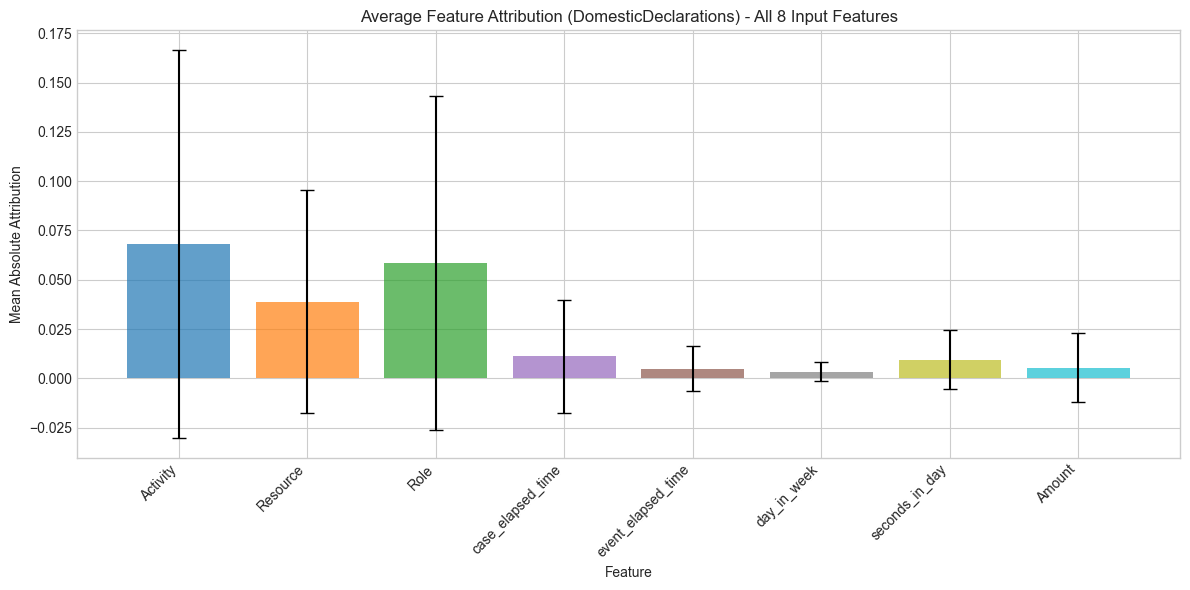

In [ ]:
# View 1: Bar chart of average attribution
fig, ax = plt.subplots(figsize=(12, 6))

# Use a colormap that scales with number of features
colors = plt.cm.tab10(np.linspace(0, 1, len(available_features)))
bars = ax.bar(available_features, avg_attribution[available_features], 
              yerr=std_attribution[available_features], capsize=5, 
              color=colors, alpha=0.7)

ax.set_ylabel('Mean Absolute Attribution')
ax.set_xlabel('Feature')
ax.set_title(f'Average Feature Attribution ({CONFIG.dataset_name}) - All {len(available_features)} Input Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

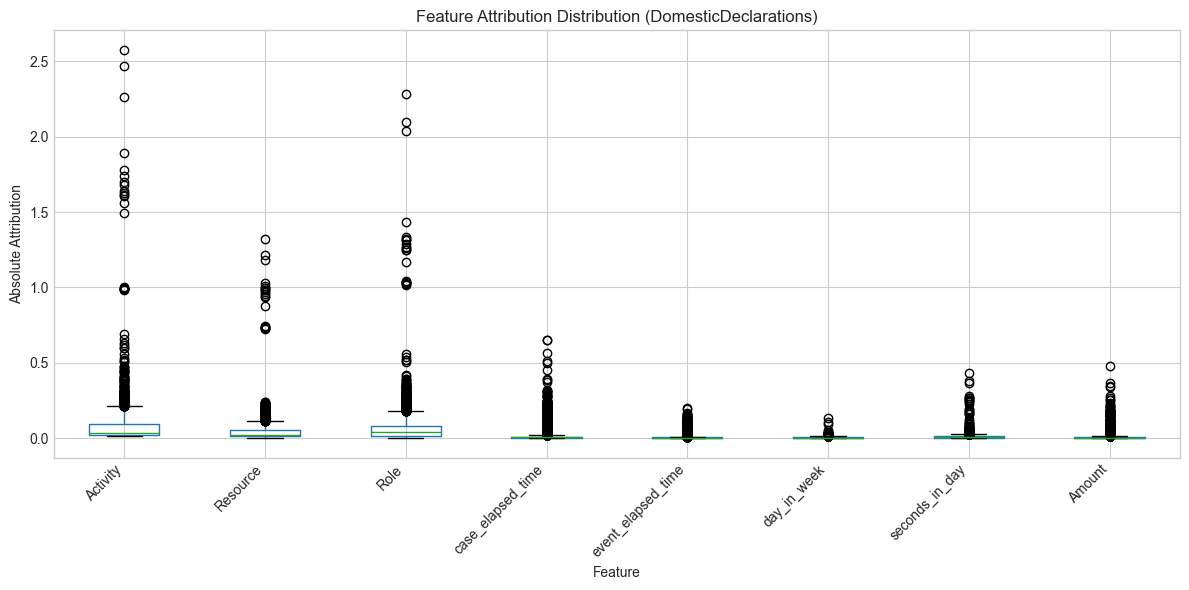

In [ ]:
# View 2: Box plots showing distribution
fig, ax = plt.subplots(figsize=(12, 6))

results_df[available_features].boxplot(ax=ax)
ax.set_ylabel('Absolute Attribution')
ax.set_xlabel('Feature')
ax.set_title(f'Feature Attribution Distribution ({CONFIG.dataset_name})')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

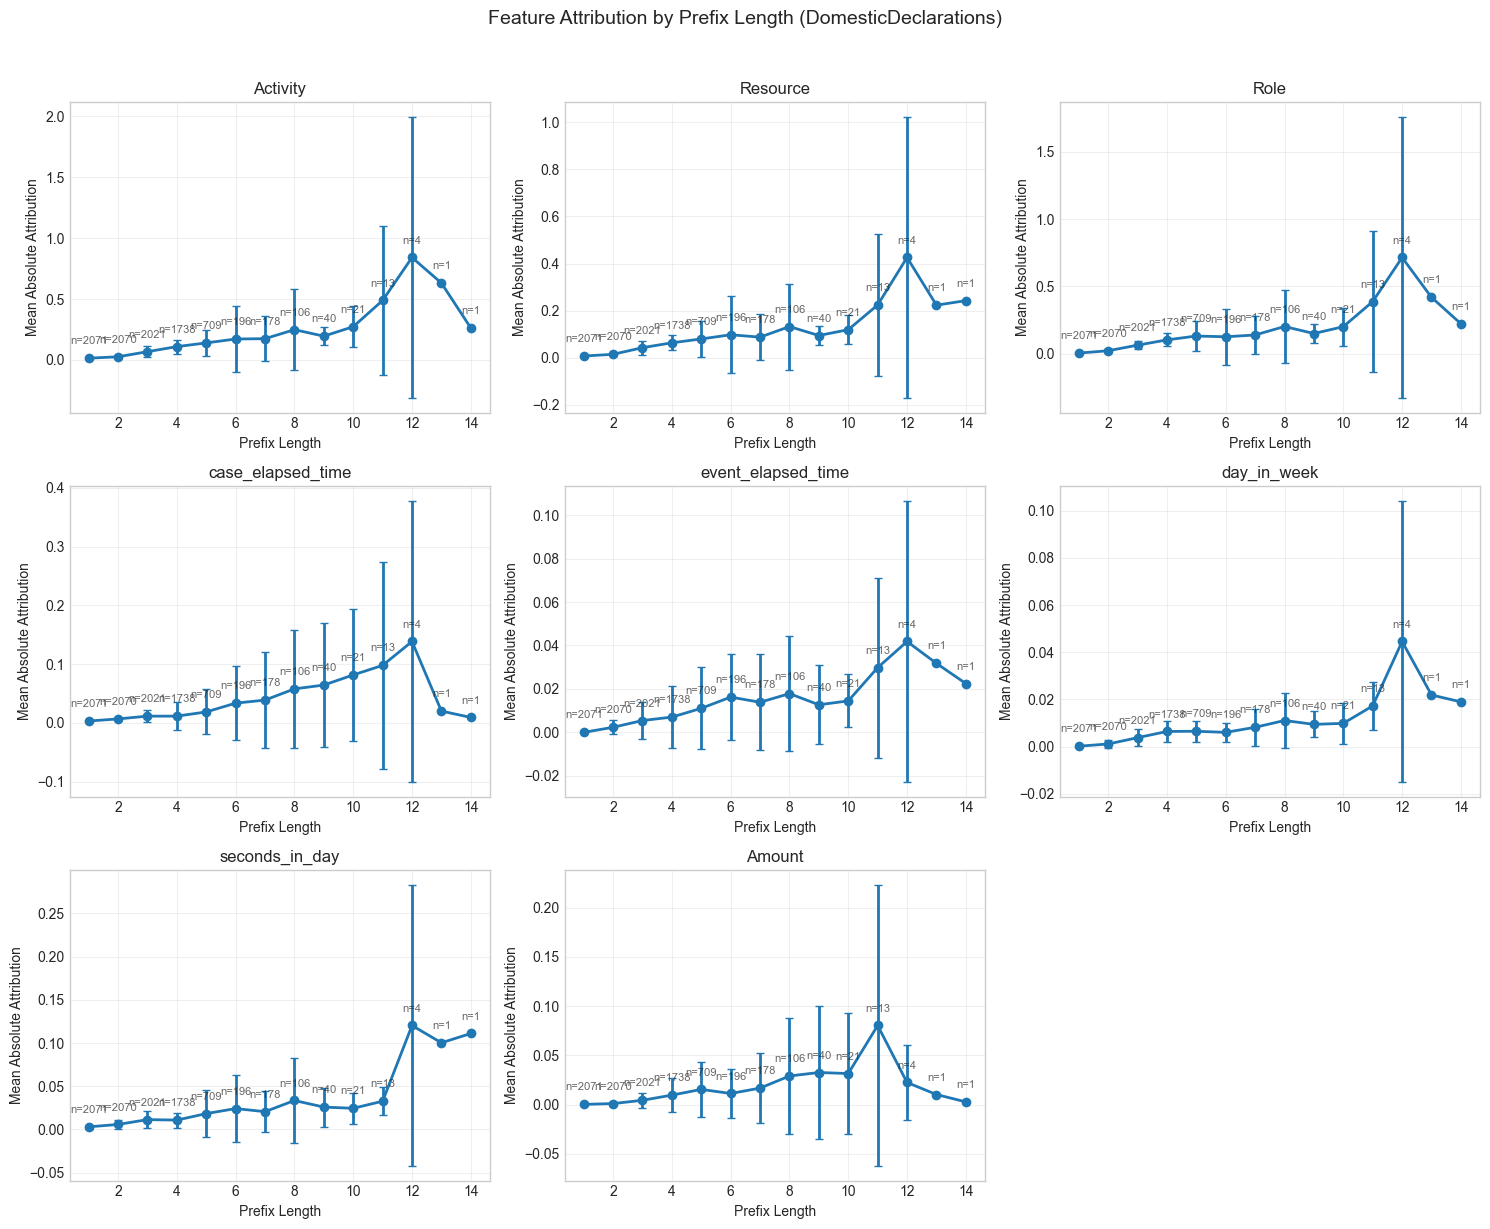


Sample distribution by prefix length:
  Prefix 1: n=2071
  Prefix 2: n=2070
  Prefix 3: n=2021
  Prefix 4: n=1738
  Prefix 5: n=709
  Prefix 6: n=196
  Prefix 7: n=178
  Prefix 8: n=106
  Prefix 9: n=40
  Prefix 10: n=21
  Prefix 11: n=13
  Prefix 12: n=4
  Prefix 13: n=1
  Prefix 14: n=1


In [ ]:
# View 3: Attribution by prefix length
n_features = len(available_features)
n_cols = min(3, n_features)
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
if n_features == 1:
    axes = [axes]
else:
    axes = axes.flatten() if n_features > 1 else [axes]

# Get sample counts per prefix length
prefix_counts = results_df.groupby('prefix_len').size()

for idx, feat in enumerate(available_features):
    ax = axes[idx]
    
    # Group by prefix length
    grouped = results_df.groupby('prefix_len')[feat].agg(['mean', 'std'])
    
    ax.errorbar(grouped.index, grouped['mean'], yerr=grouped['std'], 
                marker='o', capsize=3, linewidth=2, markersize=6)
    ax.set_xlabel('Prefix Length')
    ax.set_ylabel('Mean Absolute Attribution')
    ax.set_title(f'{feat}')
    ax.grid(True, alpha=0.3)
    
    # Add sample count annotations
    for pl in grouped.index:
        n = prefix_counts[pl]
        ax.annotate(f'n={n}', (pl, grouped.loc[pl, 'mean']), 
                    textcoords="offset points", xytext=(0, 10), 
                    ha='center', fontsize=8, alpha=0.7)

# Hide unused subplots
for idx in range(n_features, len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Feature Attribution by Prefix Length ({CONFIG.dataset_name})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print sample distribution
print("\nSample distribution by prefix length:")
for pl in sorted(prefix_counts.index):
    print(f"  Prefix {pl}: n={prefix_counts[pl]}")

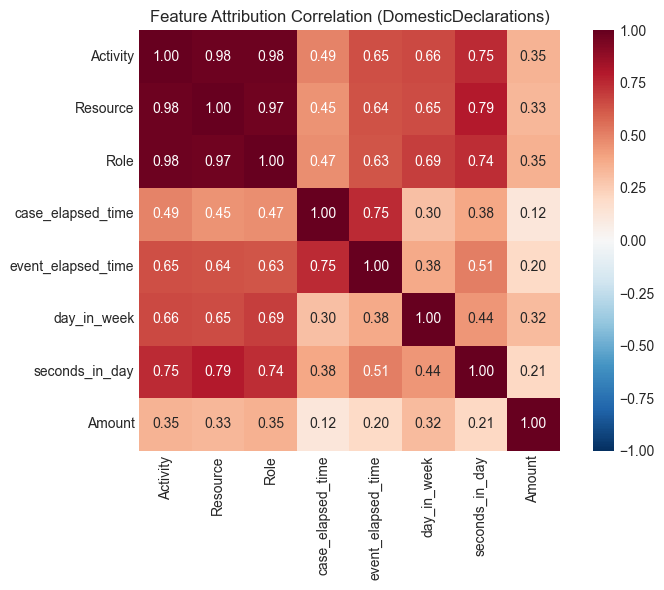

In [ ]:
# View 4: Correlation heatmap between features
if len(available_features) > 1:
    fig, ax = plt.subplots(figsize=(8, 6))
    
    corr_matrix = results_df[available_features].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0,
                fmt='.2f', ax=ax, square=True, vmin=-1, vmax=1)
    ax.set_title(f'Feature Attribution Correlation ({CONFIG.dataset_name})')
    plt.tight_layout()
    plt.show()

## 6. Attribution by Categorical Value (10 Views)

In [ ]:
# Find top-5 most common predicted activities
activity_counts = results_df['predicted_activity'].value_counts()
top_activities = activity_counts.head(5).index.tolist()

print(f"Top 5 predicted activities:")
for act in top_activities:
    print(f"  {act}: {activity_counts[act]} predictions")

Top 5 predicted activities:
  Declaration FINAL_APPROVED by SUPERVISOR: 4990 predictions
  Request Payment: 2201 predictions
  Payment Handled: 1957 predictions
  EOS: 21 predictions


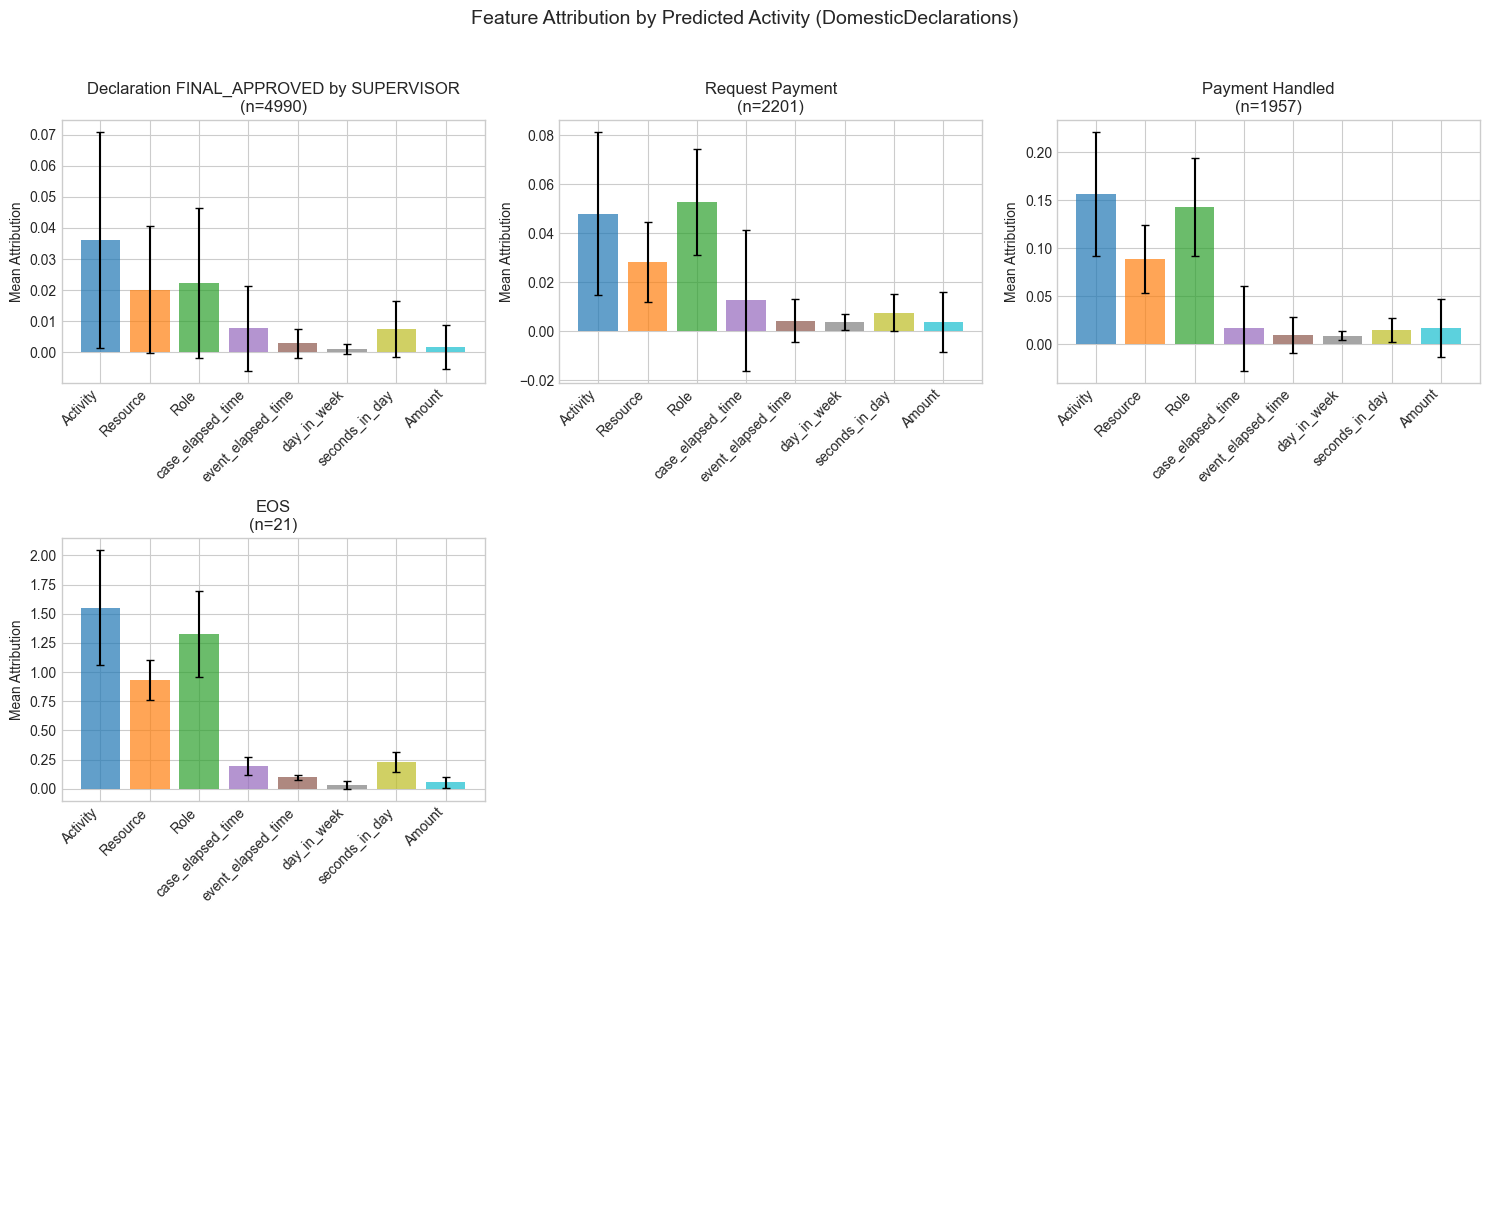

In [ ]:
# Views 1-5: Attribution for each of top-5 activities
n_activities = min(5, len(top_activities))
n_cols = min(3, n_activities)
n_rows = (n_activities + n_cols - 1) // n_cols + (1 if n_activities % n_cols != 0 else 0)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten() if n_activities > 1 else [axes]

# Use colormap for dynamic number of features
colors = plt.cm.tab10(np.linspace(0, 1, len(available_features)))

for idx, activity in enumerate(top_activities[:n_activities]):
    ax = axes[idx]
    
    # Filter to this activity
    activity_df = results_df[results_df['predicted_activity'] == activity]
    
    if len(activity_df) > 0:
        means = activity_df[available_features].mean()
        stds = activity_df[available_features].std()
        
        ax.bar(range(len(available_features)), means, yerr=stds, capsize=3,
               color=colors, alpha=0.7)
        ax.set_xticks(range(len(available_features)))
        ax.set_xticklabels(available_features, rotation=45, ha='right')
        ax.set_ylabel('Mean Attribution')
        ax.set_title(f'{activity}\n(n={len(activity_df)})')

# Hide unused subplots
for idx in range(n_activities, len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Feature Attribution by Predicted Activity ({CONFIG.dataset_name})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Summary table: Attribution by activity
activity_summary = []

for activity in top_activities:
    activity_df = results_df[results_df['predicted_activity'] == activity]
    
    row = {'Activity': activity, 'Count': len(activity_df)}
    for feat in available_features:
        row[f'{feat}_mean'] = activity_df[feat].mean()
    activity_summary.append(row)

summary_df = pd.DataFrame(activity_summary)
print("\nAttribution Summary by Predicted Activity:")
display(summary_df)


Attribution Summary by Predicted Activity:


,Activity,Count,Activity_mean,Resource_mean,Role_mean,case_elapsed_time_mean,event_elapsed_time_mean,day_in_week_mean,seconds_in_day_mean,Amount_mean
0,Declaration FINAL_APPROVED by SUPERVISOR,4990,0.036166,0.020147,0.022233,0.007749,0.002915,0.001041,0.007534,0.001640
1,Request Payment,2201,0.047991,0.028082,0.052776,0.012635,0.004373,0.003824,0.007507,0.003793
2,Payment Handled,1957,0.156400,0.088759,0.142635,0.016593,0.009535,0.008429,0.014429,0.016411
3,EOS,21,1.551908,0.931819,1.325095,0.192072,0.099130,0.034810,0.232039,0.054381


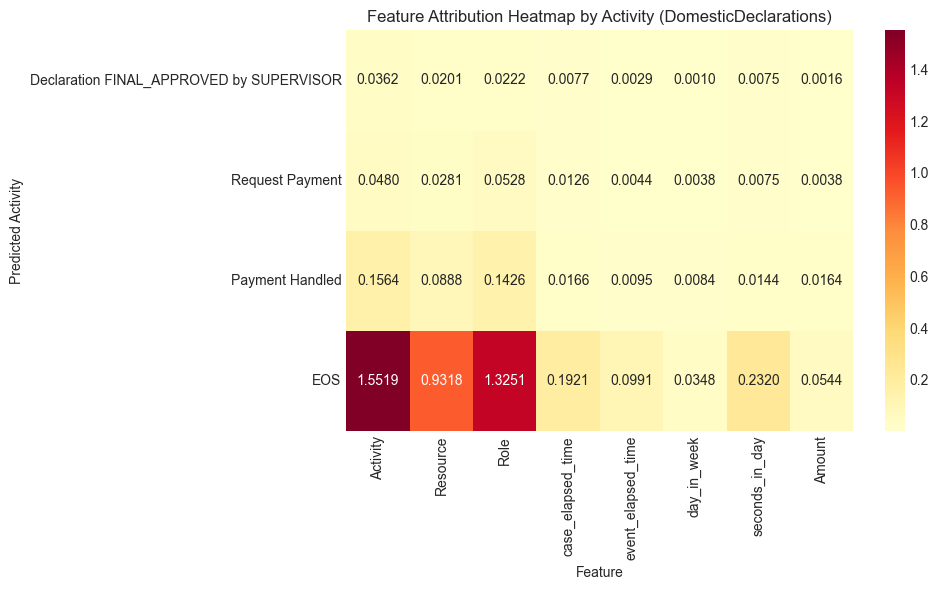

In [ ]:
# Views 6-10: Heatmap of feature attribution by activity
# Create pivot table
heatmap_data = summary_df.set_index('Activity')[[f'{f}_mean' for f in available_features]]
heatmap_data.columns = available_features

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap='YlOrRd', fmt='.4f', ax=ax)
ax.set_title(f'Feature Attribution Heatmap by Activity ({CONFIG.dataset_name})')
ax.set_ylabel('Predicted Activity')
ax.set_xlabel('Feature')
plt.tight_layout()
plt.show()

## 7. Save Results

In [ ]:
# Save results
output_dir = CONFIG.get_results_dir()

mode_suffix = '_test' if TEST_MODE else '_full'
output_path = output_dir / f'dataset_attribution_results{mode_suffix}.pkl'

with open(output_path, 'wb') as f:
    pickle.dump({
        'results_df': results_df,
        'avg_attribution': avg_attribution.to_dict(),
        'activity_summary': summary_df,
        'config': CONFIG.to_dict(),
        'test_mode': TEST_MODE
    }, f)

print(f"Results saved to: {output_path}")

Results saved to: /Users/philippeichhorn/IdeaProjects/XAI-Probabilistic_Suffix_Prediction_U-ED-LSTM_pub/src/interpretability/notebooks/results/domesticdeclarations/dataset_attribution_results_full.pkl


## 8. Summary

In [ ]:
print("="*80)
print(f"SUMMARY: Dataset-Level Attribution Analysis")
print("="*80)
print(f"\nDataset: {CONFIG.dataset_name}")
print(f"Mode: {'TEST' if TEST_MODE else 'FULL'}")
print(f"Samples analyzed: {len(results_df)}")
print(f"Total input features: {len(available_features)}")

print(f"\n--- Average Feature Attribution (All {len(available_features)} Features) ---")
# Sort by attribution value
sorted_attrs = avg_attribution[available_features].sort_values(ascending=False)
for feat in sorted_attrs.index:
    print(f"{feat:25s}: {sorted_attrs[feat]:.6f}")

print(f"\n--- Top Predicted Activities ---")
for act in top_activities[:5]:
    print(f"{act}: {activity_counts[act]} predictions")

SUMMARY: Dataset-Level Attribution Analysis

Dataset: DomesticDeclarations
Mode: FULL
Samples analyzed: 9169
Total input features: 8

--- Average Feature Attribution (All 8 Features) ---
Activity                 : 0.068139
Role                     : 0.058247
Resource                 : 0.038784
case_elapsed_time        : 0.011232
seconds_in_day           : 0.009513
Amount                   : 0.005430
event_elapsed_time       : 0.004898
day_in_week              : 0.003363

--- Top Predicted Activities ---
Declaration FINAL_APPROVED by SUPERVISOR: 4990 predictions
Request Payment: 2201 predictions
Payment Handled: 1957 predictions
EOS: 21 predictions
